In [1]:
from pyomo import *
from ortools.sat.python import cp_model
import warnings
warnings.simplefilter('ignore')

```
Job 1:
Operation 1 → M1 → 3
Operation 2 → M2 → 2

Job 2:
Operation 1 → M2 → 2
Operation 2 → M1 → 4
```

In [2]:
def basic_sample_lp():
    model = ConcreteModel()

    
    
    model.S11 = Var(domain=NonNegativeReals)
    model.S12 = Var(domain=NonNegativeReals)
    model.S21 = Var(domain=NonNegativeReals)
    model.S22 = Var(domain=NonNegativeReals)
    
    model.y1 = Var(domain=Binary) # 11<12 
    model.y2 = Var(domain=Binary) # 21<22
    
    #makespan
    model.Cmax = Var(domain=NonNegativeReals)
    
    
    # job 1 precedence
    #j1-o1 -> j1-o2
    model.j1_precedence = Constraint(expr=model.S11+3 <= model.S12)
    
    # job 2 precedence
    #j2-o1 -> j2-o2
    model.j2_precedence = Constraint(expr=model.S21+2 <= model.S22)
    
    
    # machine1 
    # j1-o1 and j2-o2
    M = 100
    
    model.machine1_1 = Constraint(expr=model.S11 + 3 <= model.S22 + M*(1-model.y1) )
    model.machine1_2 = Constraint(expr=model.S22 + 4 <= model.S11 + M*(model.y1) )
    
    # machine2
    # j1-o2 and j2-o1
    model.machine2_1 = Constraint(expr=model.S12+2 <= model.S21 + M*(1-model.y2)) 
    
    
    # makespan
    model.makespan_1 = Constraint(expr=model.Cmax >= model.S12+2)
    model.makespan_2 = Constraint(expr=model.Cmax >= model.S22+4)
    
    
    
    model.obj = Objective(expr=model.Cmax, sense=minimize)
    solver = SolverFactory("glpk")
    results = solver.solve(model)
    model.machine2_2 = Constraint(expr=model.S21+2 <= model.S12 + M*(model.y2)) 


```
Start ───── Duration ───── End
  │             │            │
  └─────────────┴────────────┘
             Interval

NewIntervalVar(), AddNoOverlap()
```

In [3]:
def basic_cp():
    model = cp_model.CpModel()
    upperbound = 3+2+2+4
    #j1-o1
    #machine1
    #duration = 3
    
    j1_o1_start = model.NewIntVar(0, upperbound, "j1_o1_start")
    j1_o1_end = model.NewIntVar(0, upperbound, "j1_o1_end")
    
    j1_o1 = model.NewIntervalVar(j1_o1_start, 3, j1_o1_end, "j1_o1")
    
    
    
    #j1-o2
    #machine2
    #duration = 2
    
    j1_o2_start = model.NewIntVar(0, upperbound, "j1_o2_start")
    j1_o2_end = model.NewIntVar(0, upperbound, "j1_o2_end")
    j1_o2 = model.NewIntervalVar(j1_o2_start, 2, j1_o2_end, "j1_o2")
    
    #j2-o1
    #machine2
    #duration = 2
    
    j2_o1_start = model.NewIntVar(0, upperbound, "j2_o1_start")
    j2_o1_end = model.NewIntVar(0, upperbound, "j2_o1_end")
    
    j2_o1 = model.NewIntervalVar(j2_o1_start, 2, j2_o1_end, "j2_o1")
    
    
    #j2-o2
    #machine1
    #duration = 4
    
    j2_o2_start = model.NewIntVar(0, upperbound, "j2_o2_start")
    j2_o2_end = model.NewIntVar(0, upperbound, "j2_o2_end")
    
    j2_o2 = model.NewIntervalVar(j2_o2_start, 4, j2_o2_end, "j2_o2")
    
    
    #precedence constraints
    model.Add(j1_o1_end<=j1_o2_start)
    model.Add(j2_o1_end<=j2_o2_start)
    
    
    
    # machine constraints 
    
    #machine1
    model.AddNoOverlap([j1_o1, j2_o2])
    model.AddNoOverlap([j1_o2, j2_o1])
    makespan = model.NewIntVar(0, upperbound, "makespan")
    model.Add(makespan >= j1_o2_end)
    model.Minimize(makespan)
    model.Add(makespan >= j2_o2_end)
    
    
    solver = cp_model.CpSolver()
    status = solver.Solve(model)
    
    
    print("Status:", solver.StatusName(status))
    print("Makespan:", solver.Value(makespan))
    
    print("J1-O1:", solver.Value(j1_o1_start),
          "->", solver.Value(j1_o1_end))
    
    print("J1-O2:", solver.Value(j1_o2_start),
          "->", solver.Value(j1_o2_end))
    
    print("J2-O1:", solver.Value(j2_o1_start),
          "->", solver.Value(j2_o1_end))
    
    print("J2-O2:", solver.Value(j2_o2_start),
          "->", solver.Value(j2_o2_end))
    print(solver.ResponseStats())

## Mathematical Model (MILP)

### Sets & Indices

- $J$: set of jobs ($j \in J$)
- $O_j$: set of operations for job $j$ ($o \in O_j$)
- $M$: set of machines

---

### Parameters

- $p_{j,o}$: processing time of operation $o$ of job $j$
- $m_{j,o}$: machine assigned to operation $(j,o)$
- $H$: large positive number (Big-M)

---

### Decision Variables

- $S_{j,o} \ge 0$: start time of operation $(j,o)$
- $C_{j,o} \ge 0$: completion time of operation $(j,o)$
- $C_{max} \ge 0$: makespan
- $y_{j,o,k,r} \in \{0,1\}$: = 1 if $(j,o)$ precedes $(k,r)$ on same machine

---

### Complete Formulation

$$
\begin{aligned}
\min \quad & C_{max} \\
\text{s.t.} \quad
& C_{j,o} = S_{j,o} + p_{j,o} && \forall j,o \\
& S_{j,o+1} \ge C_{j,o} && \forall j,o \\
& C_{j,o} \le S_{k,r} + H(1 - y_{j,o,k,r}) && \forall (j,o),(k,r): m_{j,o} = m_{k,r} \\
& C_{k,r} \le S_{j,o} + H \cdot y_{j,o,k,r} && \forall (j,o),(k,r): m_{j,o} = m_{k,r} \\
& C_{max} \ge C_{j,o_j^{last}} && \forall j \\
& S_{j,o} \ge 0, \; C_{j,o} \ge 0, \; C_{max} \ge 0 \\
& y_{j,o,k,r} \in \{0,1\}
\end{aligned}
$$

In [4]:
model = cp_model.CpModel()

In [5]:
"""
Job 0:
    Operation 0 → Machine 0 → duration 3
    Operation 1 → Machine 1 → duration 2

Job 1:
    Operation 0 → Machine 1 → duration 2
    Operation 1 → Machine 0 → duration 4
"""
jobs = {
    0: [(0, 3), (1, 2)],
    1: [(1, 2), (0, 4)],
    2: [(1, 2), (0, 4)],
}


In [6]:
num_jobs = len(jobs)
num_machines = 2

In [7]:
upperbound =  sum(duration for job in jobs.values() for machine, duration in job)

In [8]:
for j in range(num_jobs):
    print(jobs[j][0])

(0, 3)
(1, 2)
(1, 2)


In [9]:
starts = {}
ends = {}
intervals = {}

for j in range(num_jobs):
    for o, (machine, duration) in enumerate(jobs[j]):
        starts[j, o] = model.NewIntVar(
            0,
            upperbound,
            f"start_{j}_{o}"
        )

        ends[j, o] = model.NewIntVar(
            0,
            upperbound, 
            f"end_{j}_{o}"
        )

        intervals[j, o] = model.NewIntervalVar(
            starts[j, o],
            duration,
            ends[j, o],
            f"interval_{j}_{o}"
        )
        

In [10]:
for j in range(num_jobs):
    for o in range(len(jobs[j]) - 1):
        model.Add(
            ends[j,o] <= starts[j, o+1]
        )

In [11]:
machine_intervals = {
   m: []
   for m in range(num_machines)
}

In [12]:
for j in range(num_jobs):
    for o, (machine, duration) in enumerate(jobs[j]):
        machine_intervals[machine].append(
           intervals[j,o] 
        )

In [13]:
for machine in range(num_machines):
    model.AddNoOverlap(
        machine_intervals[machine]
    )

In [14]:
makespan = model.NewIntVar(
    0,
    upperbound,
    "makespan"
)

In [15]:
for j in range(num_jobs):
    last_operation = len(jobs[j]) - 1
    model.Add(makespan >= ends[j, last_operation])

In [16]:
model.Minimize(makespan)

In [17]:
solver = cp_model.CpSolver()

status = solver.Solve(model)


print("Status:", solver.StatusName(status))
print("Makespan:", solver.Value(makespan))


for j in range(num_jobs):

    for o, (machine, duration) in enumerate(jobs[j]):

        print(
            f"J{j}-O{o}: "
            f"Machine {machine}, "
            f"{solver.Value(starts[j, o])} -> "
            f"{solver.Value(ends[j, o])}"
        )

Status: OPTIMAL
Makespan: 11
J0-O0: Machine 0, 0 -> 3
J0-O1: Machine 1, 4 -> 6
J1-O0: Machine 1, 0 -> 2
J1-O1: Machine 0, 3 -> 7
J2-O0: Machine 1, 2 -> 4
J2-O1: Machine 0, 7 -> 11


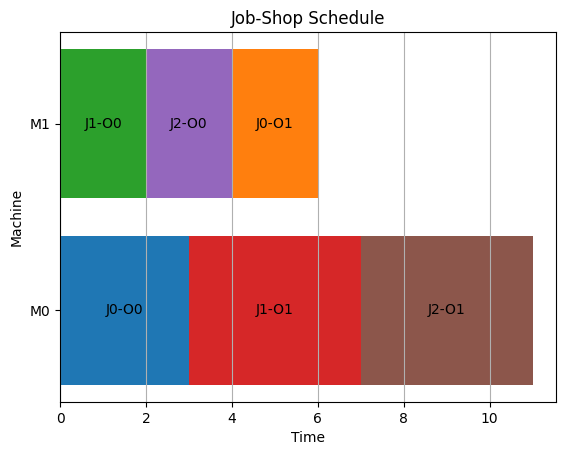

In [19]:
# Directly copy-pasted this part from AI
schedule = []

for j in range(num_jobs):
    for o, (machine, duration) in enumerate(jobs[j]):

        schedule.append({
            "job": j,
            "operation": o,
            "machine": machine,
            "start": solver.Value(starts[j, o]),
            "end": solver.Value(ends[j, o]),
        })
        
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

for item in schedule:

    job = item["job"]
    machine = item["machine"]
    start = item["start"]
    duration = item["end"] - item["start"]

    ax.barh(
        machine,
        duration,
        left=start
    )

    ax.text(
        start + duration / 2,
        machine,
        f"J{job}-O{item['operation']}",
        ha="center",
        va="center"
    )


ax.set_xlabel("Time")
ax.set_ylabel("Machine")
ax.set_yticks(range(num_machines))
ax.set_yticklabels(
    [f"M{i}" for i in range(num_machines)]
)

ax.set_title("Job-Shop Schedule")
ax.grid(axis="x")

plt.show()

In [ ]:
#TODO: Flexible Job-Shop Scheduling